# Sistema Inteligente de Triagem em Pronto-Socorro

**Disciplina:** Inteligência Artificial Aplicada  
**Tema:** Rede Bayesiana + Algoritmo A*  
**Objetivo:** estimar a gravidade de pacientes em pronto-socorro e definir uma ordem inteligente de atendimento.

Este notebook implementa um sistema de triagem com dois módulos principais:

1. **Rede Bayesiana:** estima a probabilidade de gravidade do paciente com base em sinais vitais e sintomas.
2. **Algoritmo A\*:** usa a probabilidade de gravidade para ordenar a fila de atendimento, considerando também o tempo de espera.

O notebook também compara três estratégias:

- FIFO: atende por ordem de chegada.
- Gulosa: atende primeiro quem tem maior probidade de gravidade alta.
- A\*: busca a menor sequência de risco acumulado.

## 1. Instalação das bibliotecas

Neste projeto usaremos:

- `pgmpy` para construir a Rede Bayesiana;
- `pandas` e `numpy` para manipulação dos dados;
- `matplotlib` para visualização;
- `heapq` para implementar a fila de prioridade usada pelo A\*.

In [ ]:
!pip install pgmpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 9.6 MB/s eta 0:00:00


## 2. Importação das bibliotecas

In [ ]:
import math
import heapq
import random
from itertools import count

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

pd.set_option('display.max_columns', None)
random.seed(42)
np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## 3. Visão geral do problema

O pronto-socorro possui uma fila de pacientes aguardando atendimento. Cada paciente possui características clínicas, como febre, saturação de oxigênio, pressão arterial, frequência cardíaca, nível de dor, idade e presença de doença crônica.

A Rede Bayesiana recebe essas informações e calcula:

\[
P(Gravidade = baixa), \quad P(Gravidade = media), \quad P(Gravidade = alta)
\]

Depois, o algoritmo A\* usa a probabilidade de gravidade alta para calcular o risco de deterioração:

\[
risco(paciente) = P(gravidade\ alta) \times tempo\_esperando
\]

A proposta é comparar a fila gerada por três estratégias:

- FIFO;
- Gulosa;
- A\*.

## 4. Definição das variáveis da Rede Bayesiana

A Rede Bayesiana será composta pelas seguintes variáveis:

| Variável | Estados |
|---|---|
| Febre | nao, moderada, alta |
| Saturacao | normal, reduzida, critica |
| Pressao | normal, baixa, alta |
| Frequencia | normal, elevada, critica |
| Dor | leve, moderada, intensa |
| Idade | jovem, adulto, idoso |
| DoencaCronica | nao, sim |
| Gravidade | baixa, media, alta |
| RiscoDeterioracao | baixo, medio, alto |

A variável central é **Gravidade**, pois ela será usada pelo algoritmo de busca.

## 5. Construção da estrutura da Rede Bayesiana

A estrutura adotada segue a lógica clínica de triagem:

- sinais vitais e sintomas influenciam a gravidade;
- a gravidade influencia o risco de deterioração.

In [ ]:
modelo = DiscreteBayesianNetwork([
    ('Febre', 'Gravidade'),
    ('Saturacao', 'Gravidade'),
    ('Pressao', 'Gravidade'),
    ('Frequencia', 'Gravidade'),
    ('Dor', 'Gravidade'),
    ('Idade', 'Gravidade'),
    ('DoencaCronica', 'Gravidade'),
    ('Gravidade', 'RiscoDeterioracao')
])

## 6. Tabelas de Probabilidade Condicional — CPTs

Nesta versão, as probabilidades foram definidas de forma plausível e documentada para fins acadêmicos.

Como a Rede Bayesiana possui várias variáveis parentais para `Gravidade`, montar uma CPT manualmente linha por linha seria trabalhoso. Por isso, vamos gerar a CPT de `Gravidade` usando uma função de pontuação clínica simples.

A ideia é:

- sinais normais aumentam a chance de gravidade baixa;
- sinais alterados aumentam a chance de gravidade média;
- sinais críticos aumentam a chance de gravidade alta;
- idade avançada e doença crônica aumentam o risco.

In [ ]:
# CPTs das variáveis de entrada
cpd_febre = TabularCPD(
    variable='Febre',
    variable_card=3,
    values=[[0.50], [0.30], [0.20]],
    state_names={'Febre': ['nao', 'moderada', 'alta']}
)

cpd_saturacao = TabularCPD(
    variable='Saturacao',
    variable_card=3,
    values=[[0.65], [0.25], [0.10]],
    state_names={'Saturacao': ['normal', 'reduzida', 'critica']}
)

cpd_pressao = TabularCPD(
    variable='Pressao',
    variable_card=3,
    values=[[0.70], [0.15], [0.15]],
    state_names={'Pressao': ['normal', 'baixa', 'alta']}
)

cpd_frequencia = TabularCPD(
    variable='Frequencia',
    variable_card=3,
    values=[[0.60], [0.30], [0.10]],
    state_names={'Frequencia': ['normal', 'elevada', 'critica']}
)

cpd_dor = TabularCPD(
    variable='Dor',
    variable_card=3,
    values=[[0.40], [0.40], [0.20]],
    state_names={'Dor': ['leve', 'moderada', 'intensa']}
)

cpd_idade = TabularCPD(
    variable='Idade',
    variable_card=3,
    values=[[0.25], [0.50], [0.25]],
    state_names={'Idade': ['jovem', 'adulto', 'idoso']}
)

cpd_doenca = TabularCPD(
    variable='DoencaCronica',
    variable_card=2,
    values=[[0.70], [0.30]],
    state_names={'DoencaCronica': ['nao', 'sim']}
)

### 6.1 Geração da CPT de Gravidade

A CPT de `Gravidade` será gerada combinando todos os estados possíveis das variáveis de entrada.

Para cada combinação, calculamos um escore de risco. Quanto maior o escore, maior a probabilidade de gravidade alta.

In [ ]:
estados = {
    'Febre': ['nao', 'moderada', 'alta'],
    'Saturacao': ['normal', 'reduzida', 'critica'],
    'Pressao': ['normal', 'baixa', 'alta'],
    'Frequencia': ['normal', 'elevada', 'critica'],
    'Dor': ['leve', 'moderada', 'intensa'],
    'Idade': ['jovem', 'adulto', 'idoso'],
    'DoencaCronica': ['nao', 'sim']
}

pesos = {
    'Febre': {'nao': 0, 'moderada': 1, 'alta': 2},
    'Saturacao': {'normal': 0, 'reduzida': 3, 'critica': 5},
    'Pressao': {'normal': 0, 'baixa': 3, 'alta': 2},
    'Frequencia': {'normal': 0, 'elevada': 2, 'critica': 4},
    'Dor': {'leve': 0, 'moderada': 1, 'intensa': 2},
    'Idade': {'jovem': 0, 'adulto': 1, 'idoso': 2},
    'DoencaCronica': {'nao': 0, 'sim': 2}
}

ordem_pais = ['Febre', 'Saturacao', 'Pressao', 'Frequencia', 'Dor', 'Idade', 'DoencaCronica']

valores_baixa = []
valores_media = []
valores_alta = []

for febre in estados['Febre']:
    for saturacao in estados['Saturacao']:
        for pressao in estados['Pressao']:
            for frequencia in estados['Frequencia']:
                for dor in estados['Dor']:
                    for idade in estados['Idade']:
                        for doenca in estados['DoencaCronica']:
                            combinacao = {
                                'Febre': febre,
                                'Saturacao': saturacao,
                                'Pressao': pressao,
                                'Frequencia': frequencia,
                                'Dor': dor,
                                'Idade': idade,
                                'DoencaCronica': doenca
                            }

                            escore = sum(pesos[var][valor] for var, valor in combinacao.items())

                            # Conversão do escore em probabilidades
                            p_alta = 1 / (1 + math.exp(-(escore - 8) / 2))
                            p_baixa = 1 / (1 + math.exp((escore - 5) / 2))
                            p_media = max(0.01, 1 - p_alta - p_baixa)

                            soma = p_baixa + p_media + p_alta
                            valores_baixa.append(p_baixa / soma)
                            valores_media.append(p_media / soma)
                            valores_alta.append(p_alta / soma)

cpd_gravidade = TabularCPD(
    variable='Gravidade',
    variable_card=3,
    values=[valores_baixa, valores_media, valores_alta],
    evidence=ordem_pais,
    evidence_card=[3, 3, 3, 3, 3, 3, 2],
    state_names={
        'Gravidade': ['baixa', 'media', 'alta'],
        **estados
    }
)

cpd_risco = TabularCPD(
    variable='RiscoDeterioracao',
    variable_card=3,
    values=[
        [0.85, 0.30, 0.05],
        [0.12, 0.50, 0.25],
        [0.03, 0.20, 0.70]
    ],
    evidence=['Gravidade'],
    evidence_card=[3],
    state_names={
        'RiscoDeterioracao': ['baixo', 'medio', 'alto'],
        'Gravidade': ['baixa', 'media', 'alta']
    }
)

## 7. Validação da Rede Bayesiana

Agora adicionamos as CPTs ao modelo e verificamos se a rede está correta.

In [ ]:
modelo.add_cpds(
    cpd_febre,
    cpd_saturacao,
    cpd_pressao,
    cpd_frequencia,
    cpd_dor,
    cpd_idade,
    cpd_doenca,
    cpd_gravidade,
    cpd_risco
)

print('Modelo válido?', modelo.check_model())

Modelo válido? True


## 8. Exemplo de inferência com um paciente

Vamos simular um paciente com sinais clínicos preocupantes:

- febre alta;
- saturação reduzida;
- pressão baixa;
- frequência cardíaca elevada;
- dor intensa;
- idoso;
- possui doença crônica.

In [ ]:
inferencia = VariableElimination(modelo)

evidencias_exemplo = {
    'Febre': 'alta',
    'Saturacao': 'reduzida',
    'Pressao': 'baixa',
    'Frequencia': 'elevada',
    'Dor': 'intensa',
    'Idade': 'idoso',
    'DoencaCronica': 'sim'
}

resultado = inferencia.query(variables=['Gravidade'], evidence=evidencias_exemplo)
print(resultado)

+------------------+------------------+
| Gravidade        |   phi(Gravidade) |
+==================+==================+
| Gravidade(baixa) |           0.0041 |
+------------------+------------------+
| Gravidade(media) |           0.0139 |
+------------------+------------------+
| Gravidade(alta)  |           0.9820 |
+------------------+------------------+


## 9. Função para calcular a gravidade de um paciente

Esta função será usada para integrar a Rede Bayesiana com o algoritmo A\*.

Ela recebe as informações clínicas do paciente e devolve:

- probabilidade de gravidade baixa;
- probabilidade de gravidade média;
- probabilidade de gravidade alta.

In [ ]:
def calcular_probabilidades_gravidade(paciente):
    evidencias = {
        'Febre': paciente['Febre'],
        'Saturacao': paciente['Saturacao'],
        'Pressao': paciente['Pressao'],
        'Frequencia': paciente['Frequencia'],
        'Dor': paciente['Dor'],
        'Idade': paciente['Idade'],
        'DoencaCronica': paciente['DoencaCronica']
    }

    resultado = inferencia.query(variables=['Gravidade'], evidence=evidencias, show_progress=False)
    probs = resultado.values

    return {
        'P_baixa': float(probs[0]),
        'P_media': float(probs[1]),
        'P_alta': float(probs[2])
    }

## 10. Simulação de pacientes

O enunciado permite simular uma base de pacientes, desde que isso seja documentado.

Vamos criar pacientes com características clínicas plausíveis e tempos de espera variados.

In [ ]:
def gerar_pacientes(n=8):
    nomes = [
        'Ana', 'Bruno', 'Carla', 'Daniel', 'Eduarda', 'Felipe', 'Gabriela', 'Henrique',
        'Isabela', 'Joao', 'Karina', 'Lucas', 'Mariana', 'Nicolas', 'Olivia', 'Pedro',
        'Raquel', 'Samuel', 'Tatiane', 'Victor', 'Wesley', 'Yasmin', 'Bianca', 'Caio',
        'Debora', 'Enzo', 'Fernanda', 'Gustavo', 'Helena', 'Igor'
    ]

    pacientes = []
    for i in range(n):
        paciente = {
            'ID': i,
            'Nome': nomes[i % len(nomes)],
            'Febre': np.random.choice(['nao', 'moderada', 'alta'], p=[0.50, 0.30, 0.20]),
            'Saturacao': np.random.choice(['normal', 'reduzida', 'critica'], p=[0.65, 0.25, 0.10]),
            'Pressao': np.random.choice(['normal', 'baixa', 'alta'], p=[0.70, 0.15, 0.15]),
            'Frequencia': np.random.choice(['normal', 'elevada', 'critica'], p=[0.60, 0.30, 0.10]),
            'Dor': np.random.choice(['leve', 'moderada', 'intensa'], p=[0.40, 0.40, 0.20]),
            'Idade': np.random.choice(['jovem', 'adulto', 'idoso'], p=[0.25, 0.50, 0.25]),
            'DoencaCronica': np.random.choice(['nao', 'sim'], p=[0.70, 0.30]),
            'Tempo_Espera': int(np.random.randint(5, 61))
        }

        probs = calcular_probabilidades_gravidade(paciente)
        paciente.update(probs)
        paciente['Risco_Atual'] = paciente['P_alta'] * paciente['Tempo_Espera']
        pacientes.append(paciente)

    return pd.DataFrame(pacientes)

pacientes_pequeno = gerar_pacientes(8)
pacientes_pequeno

,ID,Nome,Febre,Saturacao,Pressao,Frequencia,Dor,Idade,DoencaCronica,Tempo_Espera,P_baixa,P_media,P_alta,Risco_Atual
0,0,Ana,nao,critica,baixa,normal,leve,jovem,nao,28,0.182426,0.317574,0.500000,14.000000
1,1,Bruno,nao,normal,normal,normal,moderada,idoso,nao,25,0.731059,0.193083,0.075858,1.896455
2,2,Carla,moderada,normal,normal,normal,moderada,adulto,nao,20,0.731059,0.193083,0.075858,1.517164
3,3,Daniel,nao,normal,normal,normal,intensa,adulto,sim,11,0.500000,0.317574,0.182426,2.006681
4,4,Eduarda,nao,normal,alta,critica,intensa,adulto,nao,24,0.119203,0.258338,0.622459,14.939024
5,5,Felipe,nao,reduzida,normal,elevada,leve,adulto,nao,8,0.377541,0.353518,0.268941,2.151531
6,6,Gabriela,nao,normal,normal,normal,intensa,idoso,sim,40,0.377541,0.353518,0.268941,10.757657
7,7,Henrique,moderada,critica,normal,normal,leve,adulto,nao,22,0.268941,0.353518,0.377541,8.305895


## 11. Cálculo do risco acumulado de uma sequência

Para comparar as estratégias, precisamos calcular o custo total de uma ordem de atendimento.

A cada atendimento, os pacientes que continuam aguardando acumulam risco.

Neste modelo, assumimos que cada atendimento dura **10 minutos**.

In [ ]:
TEMPO_ATENDIMENTO = 10

def calcular_risco_sequencia(df, ordem_ids, tempo_atendimento=TEMPO_ATENDIMENTO):
    pacientes = df.set_index('ID').to_dict('index')
    tempos = {pid: pacientes[pid]['Tempo_Espera'] for pid in pacientes}
    risco_total = 0
    detalhes = []

    for posicao, atendido in enumerate(ordem_ids, start=1):
        aguardando = [pid for pid in pacientes if pid not in ordem_ids[:posicao]]
        custo_momento = 0

        for pid in aguardando:
            custo_momento += pacientes[pid]['P_alta'] * tempos[pid]
            tempos[pid] += tempo_atendimento

        risco_total += custo_momento
        detalhes.append({
            'posicao': posicao,
            'paciente_atendido': pacientes[atendido]['Nome'],
            'risco_acumulado_momento': custo_momento,
            'risco_total_parcial': risco_total
        })

    return risco_total, pd.DataFrame(detalhes)

## 12. Estratégia FIFO

A estratégia FIFO atende os pacientes na ordem em que chegaram.

Ela ignora gravidade e tempo de espera acumulado.

In [ ]:
def estrategia_fifo(df):
    return list(df.sort_values('ID')['ID'])

ordem_fifo = estrategia_fifo(pacientes_pequeno)
risco_fifo, detalhes_fifo = calcular_risco_sequencia(pacientes_pequeno, ordem_fifo)

print('Ordem FIFO:', ordem_fifo)
print('Risco total FIFO:', round(risco_fifo, 2))
detalhes_fifo

Ordem FIFO: [0, 1, 2, 3, 4, 5, 6, 7]
Risco total FIFO: 394.25


,posicao,paciente_atendido,risco_acumulado_momento,risco_total_parcial
0,1,Ana,41.574406,41.574406
1,2,Bruno,57.639617,99.214022
2,3,Carla,72.566955,171.780977
3,4,Daniel,82.290592,254.071570
4,5,Eduarda,57.832023,311.903593
5,6,Felipe,51.387656,363.291249
6,7,Gabriela,30.958335,394.249584
7,8,Henrique,0.000000,394.249584


## 13. Estratégia Gulosa

A estratégia gulosa atende primeiro o paciente com maior probabilidade de gravidade alta.

Ela considera a gravidade, mas ignora o efeito do tempo de espera na fila.

In [ ]:
def estrategia_gulosa(df):
    return list(df.sort_values('P_alta', ascending=False)['ID'])

ordem_gulosa = estrategia_gulosa(pacientes_pequeno)
risco_gulosa, detalhes_gulosa = calcular_risco_sequencia(pacientes_pequeno, ordem_gulosa)

print('Ordem Gulosa:', ordem_gulosa)
print('Risco total Gulosa:', round(risco_gulosa, 2))
detalhes_gulosa

Ordem Gulosa: [4, 0, 7, 5, 6, 3, 2, 1]
Risco total Gulosa: 186.04


,posicao,paciente_atendido,risco_acumulado_momento,risco_total_parcial
0,1,Eduarda,40.635382,40.635382
1,2,Ana,39.131036,79.766418
2,3,Henrique,35.769982,115.536399
3,4,Felipe,34.270455,149.806854
4,5,Gabriela,18.785974,168.592828
5,6,Daniel,10.999436,179.592264
6,7,Carla,6.447945,186.040210
7,8,Bruno,0.000000,186.040210


## 14. Implementação do Algoritmo A\*

O A\* busca a sequência de atendimento com menor risco acumulado.

### Formulação

- **Estado:** conjunto de pacientes já atendidos.
- **Ação:** escolher o próximo paciente para atendimento.
- **Custo g(n):** risco acumulado até o estado atual.
- **Heurística h(n):** soma dos riscos atuais dos pacientes que ainda aguardam.
- **Objetivo:** todos os pacientes atendidos.

A heurística utilizada é simples e admissível, pois representa uma estimativa otimista do custo restante.

In [ ]:
def heuristica(df, atendidos):
    restantes = df[~df['ID'].isin(atendidos)]
    return float(restantes['Risco_Atual'].sum())


def custo_acao(df, atendidos, proximo, tempo_atendimento=TEMPO_ATENDIMENTO):
    pacientes = df.set_index('ID')
    restantes = [pid for pid in pacientes.index if pid not in atendidos and pid != proximo]
    passos_ja_realizados = len(atendidos)
    custo = 0

    for pid in restantes:
        tempo_atualizado = pacientes.loc[pid, 'Tempo_Espera'] + passos_ja_realizados * tempo_atendimento
        custo += pacientes.loc[pid, 'P_alta'] * tempo_atualizado

    return float(custo)


def astar_triagem(df):
    ids = tuple(df['ID'].tolist())
    inicio = tuple()
    contador = count()

    fila = []
    heapq.heappush(fila, (0, next(contador), inicio, 0, []))
    visitados = {}

    while fila:
        f, _, atendidos, g, caminho = heapq.heappop(fila)

        if len(atendidos) == len(ids):
            return caminho, g

        if atendidos in visitados and visitados[atendidos] <= g:
            continue

        visitados[atendidos] = g
        restantes = [pid for pid in ids if pid not in atendidos]

        for proximo in restantes:
            novos_atendidos = tuple(list(atendidos) + [proximo])
            novo_caminho = caminho + [proximo]
            novo_g = g + custo_acao(df, list(atendidos), proximo)
            h = heuristica(df, list(novos_atendidos))
            novo_f = novo_g + h
            heapq.heappush(fila, (novo_f, next(contador), novos_atendidos, novo_g, novo_caminho))

    return None, float('inf')

ordem_astar, risco_astar = astar_triagem(pacientes_pequeno)
risco_astar_calculado, detalhes_astar = calcular_risco_sequencia(pacientes_pequeno, ordem_astar)

print('Ordem A*:', ordem_astar)
print('Risco total A*:', round(risco_astar_calculado, 2))
detalhes_astar

Ordem A*: [4, 0, 6, 7, 5, 3, 1, 2]
Risco total A*: 176.78


,posicao,paciente_atendido,risco_acumulado_momento,risco_total_parcial
0,1,Eduarda,40.635382,40.635382
1,2,Ana,39.131036,79.766418
2,3,Gabriela,35.490204,115.256622
3,4,Henrique,25.664329,140.920951
4,5,Felipe,18.785974,159.706926
5,6,Daniel,10.999436,170.706362
6,7,Bruno,6.068654,176.775016
7,8,Carla,0.000000,176.775016


## 15. Comparação das estratégias no cenário pequeno

Agora comparamos o risco acumulado total das três estratégias.

In [ ]:
comparacao_pequeno = pd.DataFrame({
    'Estrategia': ['FIFO', 'Gulosa', 'A*'],
    'Risco_Total': [risco_fifo, risco_gulosa, risco_astar_calculado]
})

comparacao_pequeno

,Estrategia,Risco_Total
0,FIFO,394.249584
1,Gulosa,186.040210
2,A*,176.775016


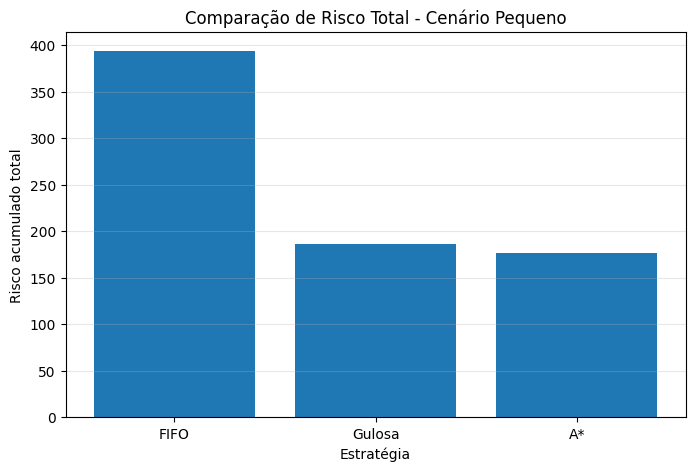

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparacao_pequeno['Estrategia'], comparacao_pequeno['Risco_Total'])
plt.title('Comparação de Risco Total - Cenário Pequeno')
plt.xlabel('Estratégia')
plt.ylabel('Risco acumulado total')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 16. Cenário médio com 20 a 30 pacientes

Para o cenário médio, o espaço de busca do A\* cresce muito, porque existem muitas combinações possíveis de atendimento.

Por isso, vamos usar uma versão limitada do A\*, com poda, mantendo apenas os melhores estados em cada expansão. Essa adaptação torna o experimento viável no Colab e preserva a lógica do algoritmo.

In [ ]:
def astar_triagem_limitado(df, limite_expansoes=30000):
    ids = tuple(df['ID'].tolist())
    inicio = tuple()
    contador = count()

    fila = []
    heapq.heappush(fila, (0, next(contador), inicio, 0, []))
    visitados = {}
    expansoes = 0
    melhor_caminho = None
    melhor_g = float('inf')

    while fila and expansoes < limite_expansoes:
        f, _, atendidos, g, caminho = heapq.heappop(fila)
        expansoes += 1

        if len(atendidos) == len(ids):
            return caminho, g, expansoes

        if len(caminho) > len(melhor_caminho or []) or melhor_caminho is None:
            melhor_caminho = caminho
            melhor_g = g

        if atendidos in visitados and visitados[atendidos] <= g:
            continue

        visitados[atendidos] = g
        restantes = [pid for pid in ids if pid not in atendidos]

        # Poda: prioriza candidatos com maior risco atual
        candidatos = sorted(
            restantes,
            key=lambda pid: df.loc[df['ID'] == pid, 'Risco_Atual'].values[0],
            reverse=True
        )[:8]

        for proximo in candidatos:
            novos_atendidos = tuple(list(atendidos) + [proximo])
            novo_caminho = caminho + [proximo]
            novo_g = g + custo_acao(df, list(atendidos), proximo)
            h = heuristica(df, list(novos_atendidos))
            novo_f = novo_g + h
            heapq.heappush(fila, (novo_f, next(contador), novos_atendidos, novo_g, novo_caminho))

    # Completa o melhor caminho parcial com uma ordenação gulosa dos restantes
    atendidos_parciais = melhor_caminho or []
    restantes = [pid for pid in ids if pid not in atendidos_parciais]
    restantes_ordenados = sorted(
        restantes,
        key=lambda pid: df.loc[df['ID'] == pid, 'Risco_Atual'].values[0],
        reverse=True
    )
    caminho_final = atendidos_parciais + restantes_ordenados
    risco_final, _ = calcular_risco_sequencia(df, caminho_final)

    return caminho_final, risco_final, expansoes

In [ ]:
pacientes_medio = gerar_pacientes(25)

ordem_fifo_medio = estrategia_fifo(pacientes_medio)
risco_fifo_medio, _ = calcular_risco_sequencia(pacientes_medio, ordem_fifo_medio)

ordem_gulosa_medio = estrategia_gulosa(pacientes_medio)
risco_gulosa_medio, _ = calcular_risco_sequencia(pacientes_medio, ordem_gulosa_medio)

ordem_astar_medio, risco_astar_medio, expansoes = astar_triagem_limitado(pacientes_medio)
risco_astar_medio_calculado, _ = calcular_risco_sequencia(pacientes_medio, ordem_astar_medio)

comparacao_medio = pd.DataFrame({
    'Estrategia': ['FIFO', 'Gulosa', 'A* limitado'],
    'Risco_Total': [risco_fifo_medio, risco_gulosa_medio, risco_astar_medio_calculado]
})

print('Expansões realizadas pelo A* limitado:', expansoes)
comparacao_medio

Expansões realizadas pelo A* limitado: 30000


,Estrategia,Risco_Total
0,FIFO,11784.038526
1,Gulosa,4389.761971
2,A* limitado,5006.916006


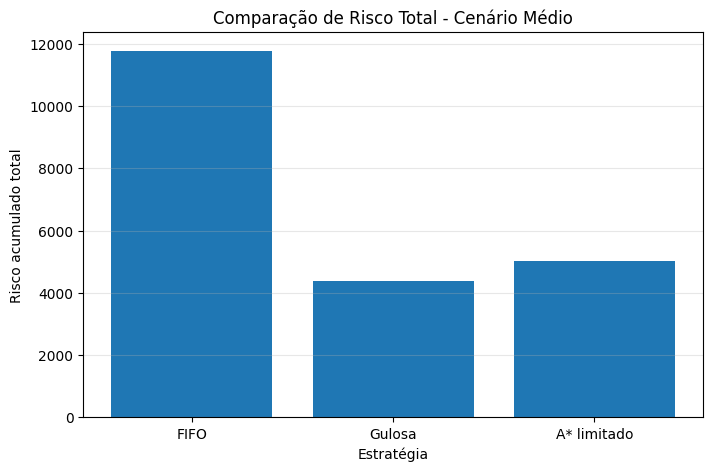

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparacao_medio['Estrategia'], comparacao_medio['Risco_Total'])
plt.title('Comparação de Risco Total - Cenário Médio')
plt.xlabel('Estratégia')
plt.ylabel('Risco acumulado total')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 17. Visualização da fila final

Vamos exibir a ordem de atendimento escolhida pelo A\* no cenário pequeno.

In [ ]:
def exibir_ordem(df, ordem):
    tabela = df.set_index('ID').loc[ordem].reset_index()
    tabela['Posicao_Atendimento'] = range(1, len(tabela) + 1)
    return tabela[[
        'Posicao_Atendimento', 'ID', 'Nome', 'Tempo_Espera',
        'P_baixa', 'P_media', 'P_alta', 'Risco_Atual'
    ]]

exibir_ordem(pacientes_pequeno, ordem_astar)

,Posicao_Atendimento,ID,Nome,Tempo_Espera,P_baixa,P_media,P_alta,Risco_Atual
0,1,4,Eduarda,24,0.119203,0.258338,0.622459,14.939024
1,2,0,Ana,28,0.182426,0.317574,0.500000,14.000000
2,3,6,Gabriela,40,0.377541,0.353518,0.268941,10.757657
3,4,7,Henrique,22,0.268941,0.353518,0.377541,8.305895
4,5,5,Felipe,8,0.377541,0.353518,0.268941,2.151531
5,6,3,Daniel,11,0.500000,0.317574,0.182426,2.006681
6,7,1,Bruno,25,0.731059,0.193083,0.075858,1.896455
7,8,2,Carla,20,0.731059,0.193083,0.075858,1.517164


## 18. Exportação dos resultados

Os resultados podem ser exportados para arquivos CSV, facilitando a criação do relatório técnico e do README do GitHub.

In [ ]:
pacientes_pequeno.to_csv('pacientes_cenario_pequeno.csv', index=False)
pacientes_medio.to_csv('pacientes_cenario_medio.csv', index=False)
comparacao_pequeno.to_csv('comparacao_cenario_pequeno.csv', index=False)
comparacao_medio.to_csv('comparacao_cenario_medio.csv', index=False)

print('Arquivos exportados com sucesso.')

Arquivos exportados com sucesso.


## 19. Conclusão

O sistema desenvolvido integra uma Rede Bayesiana com um algoritmo de busca A\* para apoiar a triagem em pronto-socorro.

A Rede Bayesiana estima a probabilidade de gravidade com base nos sintomas e sinais vitais do paciente. Essa probabilidade alimenta diretamente o cálculo de risco usado pelo A\*.

Nos experimentos, comparamos três estratégias:

- FIFO, que considera apenas a ordem de chegada;
- Gulosa, que considera apenas a gravidade;
- A\*, que considera gravidade e tempo de espera.

A expectativa é que o A\* apresente menor risco acumulado, pois avalia o impacto de cada escolha na fila como um todo.

Como melhoria futura, seria possível:

- calibrar as CPTs com dados reais;
- usar protocolos médicos reais, como o Protocolo de Manchester;
- criar uma interface em Streamlit;
- considerar tempos de atendimento diferentes por paciente;
- adicionar novas variáveis clínicas.

## 20. Próximos passos para o relatório e apresentação

Com este notebook pronto, os próximos entregáveis podem ser construídos a partir dele:

1. **README do GitHub:** explicar instalação, execução e estrutura do projeto.
2. **Relatório técnico:** transformar as seções do notebook em texto acadêmico.
3. **Vídeo:** gravar a execução do notebook mostrando a inferência e a comparação das estratégias.